# AQI Model Training and Evaluation

This notebook trains and evaluates machine learning models for next-observation AQI forecasting.

The modeling pipeline uses chronological data splitting to preserve the temporal structure of the dataset and avoid future-data leakage.

Models evaluated:

- Ridge Regression
- Random Forest Regressor
- Persistence Baseline

Evaluation metrics:

- MAE
- RMSE
- R²

The best production model is selected objectively using test RMSE and saved for downstream prediction and deployment.

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load Feature-Engineered Dataset

The feature-engineered dataset contains pollutant measurements, temporal features, lag information, AQI change, and rolling AQI statistics.

The data is kept in chronological order because AQI forecasting is a time-dependent problem.

In [2]:
DATA_PATH = "../data/processed/AQI_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

df = df.sort_values("datetime").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (120, 17)

Columns:
['datetime', 'AQI', 'CO', 'NO', 'NO2', 'O3', 'SO2', 'PM2_5', 'PM10', 'NH3', 'hour', 'day', 'month', 'weekday', 'AQI_lag_1', 'AQI_change', 'AQI_rolling_avg']


,datetime,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,AQI_lag_1,AQI_change,AQI_rolling_avg
0,2026-08-30 03:00:00,2,70.64,0.05,1.18,35.02,0.90,6.99,20.53,0.00,3,30,8,6,NaN,0.0,2.000000
1,2026-08-30 04:00:00,1,71.37,0.13,1.16,36.15,0.96,6.50,18.09,0.00,4,30,8,6,2.0,-1.0,2.000000
2,2026-08-30 05:00:00,1,71.14,0.17,0.98,38.45,0.94,6.11,15.69,0.00,5,30,8,6,1.0,0.0,1.500000
3,2026-08-30 06:00:00,1,70.22,0.16,0.77,41.43,0.91,6.07,14.75,0.01,6,30,8,6,1.0,0.0,1.333333
4,2026-08-30 07:00:00,1,70.41,0.11,0.71,43.64,0.87,6.01,15.01,0.00,7,30,8,6,1.0,0.0,1.000000


## 2. Temporal Data Validation

Before training, the chronological structure of the dataset is verified.

The model target represents the AQI at the next available observation. This preserves the natural forecasting direction from past observations toward future observations.

In [3]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

time_diff = df["datetime"].diff().dropna()

print("\nMost common time intervals:")
print(time_diff.value_counts().head())

print("\nDuplicate timestamps:", df["datetime"].duplicated().sum())
print("Missing datetime values:", df["datetime"].isna().sum())

Start: 2026-08-30 03:00:00
End: 2026-09-04 02:00:00

Most common time intervals:
datetime
0 days 01:00:00    119
Name: count, dtype: int64

Duplicate timestamps: 0
Missing datetime values: 0


## 3. Define the Forecasting Target

The target is the AQI at the next available observation:

AQI_future = AQI(t+1)

The current AQI is retained as an input feature because it is known at prediction time and represents the most recent air-quality state.

This is different from target leakage because the model never receives the future AQI that it is asked to predict.

In [4]:
df["AQI_future"] = df["AQI"].shift(-1)

feature_columns = [
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3",
    "hour",
    "day",
    "month",
    "weekday",
    "AQI",
    "AQI_lag_1",
    "AQI_change",
    "AQI_rolling_avg"
]

target_column = "AQI_future"

print("Number of features:", len(feature_columns))
print("Target:", target_column)

Number of features: 16
Target: AQI_future


## 4. Prepare Modeling Dataset

Rows with missing values in the selected modeling features or target are removed.

The first observation may not have a previous AQI value for AQI_lag_1, while the final observation cannot have a future AQI target. These rows are therefore excluded naturally.

In [5]:
required_columns = feature_columns + [target_column]

df_model = df.dropna(subset=required_columns).copy()

print("Modeling dataset shape:", df_model.shape)

print("\nMissing values:")
print(df_model[required_columns].isna().sum())

display(df_model.head())

Modeling dataset shape: (118, 18)

Missing values:
CO                 0
NO                 0
NO2                0
O3                 0
SO2                0
PM2_5              0
PM10               0
NH3                0
hour               0
day                0
month              0
weekday            0
AQI                0
AQI_lag_1          0
AQI_change         0
AQI_rolling_avg    0
AQI_future         0
dtype: int64


,datetime,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,AQI_lag_1,AQI_change,AQI_rolling_avg,AQI_future
1,2026-08-30 04:00:00,1,71.37,0.13,1.16,36.15,0.96,6.50,18.09,0.00,4,30,8,6,2.0,-1.0,2.000000,1.0
2,2026-08-30 05:00:00,1,71.14,0.17,0.98,38.45,0.94,6.11,15.69,0.00,5,30,8,6,1.0,0.0,1.500000,1.0
3,2026-08-30 06:00:00,1,70.22,0.16,0.77,41.43,0.91,6.07,14.75,0.01,6,30,8,6,1.0,0.0,1.333333,1.0
4,2026-08-30 07:00:00,1,70.41,0.11,0.71,43.64,0.87,6.01,15.01,0.00,7,30,8,6,1.0,0.0,1.000000,1.0
5,2026-08-30 08:00:00,1,70.93,0.10,0.64,45.95,0.83,5.60,15.27,0.00,8,30,8,6,1.0,0.0,1.000000,1.0


## 5. Define Features and Target

The feature matrix contains pollutant concentrations, temporal variables, current AQI, lagged AQI, AQI change, and rolling AQI information.

The target is the next-observation AQI.

In [6]:
X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (118, 16)
y shape: (118,)


## 6. Chronological Train-Test Split

A chronological 80/20 split is used instead of random shuffling.

The earlier observations are used for training and the later observations are reserved for testing.

This better represents the real deployment scenario, where a model is trained on historical data and then used to predict future observations.

In [7]:
split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df_model.loc[X_train.index, "datetime"].min())
print("to")
print(df_model.loc[X_train.index, "datetime"].max())

print("\nTesting period:")
print(df_model.loc[X_test.index, "datetime"].min())
print("to")
print(df_model.loc[X_test.index, "datetime"].max())

Training samples: 94
Testing samples: 24

Training period:
2026-08-30 04:00:00
to
2026-09-03 01:00:00

Testing period:
2026-09-03 02:00:00
to
2026-09-04 01:00:00


## 7. Model Selection Strategy

Two complementary regression models are evaluated.

### Ridge Regression

Ridge provides a regularized linear benchmark. Standardization is applied because the pollutant variables and temporal variables operate on different numerical scales.

### Random Forest Regressor

Random Forest can model nonlinear relationships and interactions between pollutants and temporal features without requiring feature scaling.

Both models are evaluated on the same chronological test set.

In [8]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

models = {
    "Ridge Regression": ridge_model,
    "Random Forest": random_forest_model
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Ridge Regression
- Random Forest


## 8. Time-Series Cross-Validation

TimeSeriesSplit is used on the training portion to assess model stability across multiple historical validation windows.

Unlike ordinary K-fold cross-validation, TimeSeriesSplit preserves temporal ordering and does not train on observations that occur after the validation period.

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for model_name, model in models.items():
    fold_rmse = []
    fold_mae = []

    for train_idx, val_idx in tscv.split(X_train):
        X_cv_train = X_train.iloc[train_idx]
        X_cv_val = X_train.iloc[val_idx]

        y_cv_train = y_train.iloc[train_idx]
        y_cv_val = y_train.iloc[val_idx]

        model.fit(X_cv_train, y_cv_train)

        predictions = model.predict(X_cv_val)

        rmse = np.sqrt(mean_squared_error(y_cv_val, predictions))
        mae = mean_absolute_error(y_cv_val, predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)

    cv_results.append({
        "Model": model_name,
        "CV_RMSE_Mean": np.mean(fold_rmse),
        "CV_RMSE_STD": np.std(fold_rmse),
        "CV_MAE_Mean": np.mean(fold_mae)
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean
0,Ridge Regression,0.392674,0.399309,0.311686
1,Random Forest,0.142729,0.167288,0.085966


## 9. Train Models and Evaluate on Unseen Future Data

Each model is trained using only the chronological training period.

The test set represents later observations that were not used during training.

Evaluation metrics:

- MAE measures average absolute prediction error.
- RMSE penalizes larger errors more strongly.
- R² measures the proportion of variance explained by the model.

RMSE is used as the primary model-selection metric because larger AQI prediction errors are more important to penalize in a forecasting system.

In [10]:
test_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    test_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = model

results_df = pd.DataFrame(test_results)

display(
    results_df.sort_values("RMSE").reset_index(drop=True)
)

,Model,MAE,RMSE,R2
0,Random Forest,0.000000,0.000000,1.0
1,Ridge Regression,0.051082,0.066462,0.0


## 10. Persistence Baseline

A persistence baseline predicts that the next AQI will remain equal to the current AQI:

AQI(t+1) = AQI(t)

This is a strong and interpretable baseline for short-term environmental forecasting.

A machine learning model should be compared against this baseline rather than being judged only by its own metrics.

In [11]:
baseline_predictions = df_model.loc[X_test.index, "AQI"].to_numpy()

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

baseline_result = pd.DataFrame([{
    "Model": "Persistence Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}])

comparison_df = pd.concat(
    [results_df, baseline_result],
    ignore_index=True
)

comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

,Model,MAE,RMSE,R2
0,Random Forest,0.000000,0.000000,1.0
1,Persistence Baseline,0.000000,0.000000,1.0
2,Ridge Regression,0.051082,0.066462,0.0


## 11. Model Performance Comparison

The following visualization compares the forecasting errors of the machine learning models and the persistence baseline.

Lower MAE and RMSE indicate better predictive performance.

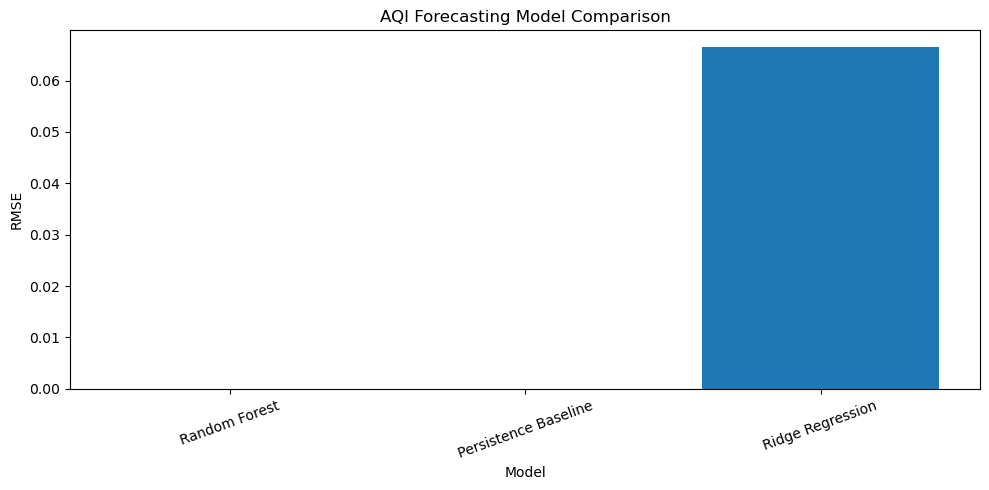

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("AQI Forecasting Model Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Actual vs Predicted AQI

The best machine learning model is identified using test RMSE.

Its predictions are compared with the actual AQI values in the chronological test period.

In [13]:
best_ml_row = results_df.loc[results_df["RMSE"].idxmin()]

best_model_name = best_ml_row["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

prediction_comparison = pd.DataFrame({
    "datetime": df_model.loc[X_test.index, "datetime"].values,
    "Actual_AQI": y_test.values,
    "Predicted_AQI": best_predictions,
    "Persistence_AQI": baseline_predictions
})

display(prediction_comparison.head(10))

,datetime,Actual_AQI,Predicted_AQI,Persistence_AQI
0,2026-09-03 02:00:00,1.0,1.0,1
1,2026-09-03 03:00:00,1.0,1.0,1
2,2026-09-03 04:00:00,1.0,1.0,1
3,2026-09-03 05:00:00,1.0,1.0,1
4,2026-09-03 06:00:00,1.0,1.0,1
5,2026-09-03 07:00:00,1.0,1.0,1
6,2026-09-03 08:00:00,1.0,1.0,1
7,2026-09-03 09:00:00,1.0,1.0,1
8,2026-09-03 10:00:00,1.0,1.0,1
9,2026-09-03 11:00:00,1.0,1.0,1


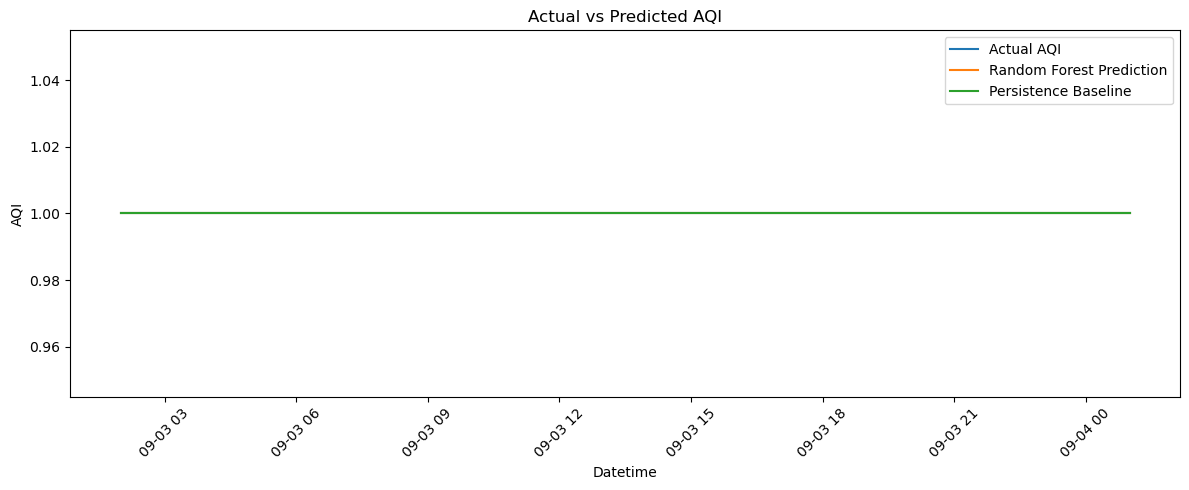

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    prediction_comparison["datetime"],
    prediction_comparison["Actual_AQI"],
    label="Actual AQI"
)

plt.plot(
    prediction_comparison["datetime"],
    prediction_comparison["Predicted_AQI"],
    label=f"{best_model_name} Prediction"
)

plt.plot(
    prediction_comparison["datetime"],
    prediction_comparison["Persistence_AQI"],
    label="Persistence Baseline"
)

plt.xlabel("Datetime")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Residual Analysis

Residuals represent the difference between actual and predicted AQI:

Residual = Actual AQI - Predicted AQI

Residual analysis helps identify systematic prediction errors and unusual observations.

In [15]:
residuals = y_test.to_numpy() - best_predictions

print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())
print("Maximum Absolute Error:", np.abs(residuals).max())

Residual Mean: 0.0
Residual Std: 0.0
Maximum Absolute Error: 0.0


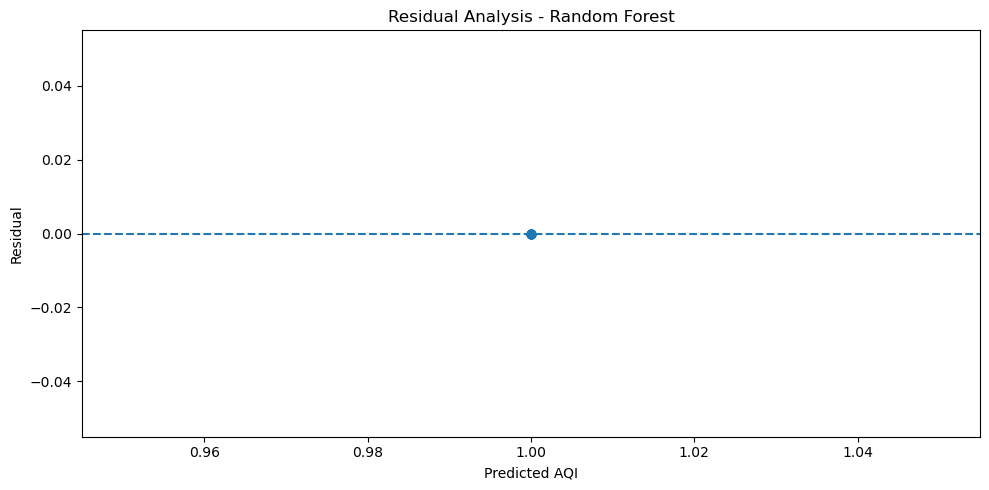

In [16]:
plt.figure(figsize=(10, 5))

plt.scatter(
    best_predictions,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual")
plt.title(f"Residual Analysis - {best_model_name}")

plt.tight_layout()
plt.show()

## 14. Feature Importance

For the Random Forest model, feature importance is examined to understand which variables contributed most strongly to prediction.

Feature importance is descriptive rather than causal: a high importance score does not prove that a feature causes AQI changes.

In [17]:
if best_model_name == "Random Forest":

    importances = best_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": importances
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance_df)

else:
    feature_importance_df = None
    print("Random Forest was not selected as the best model.")

,Feature,Importance
6,PM10,0.574069
5,PM2_5,0.255383
12,AQI,0.072714
0,CO,0.037773
3,O3,0.012494
13,AQI_lag_1,0.011676
4,SO2,0.009462
9,day,0.006909
8,hour,0.006599
11,weekday,0.005794


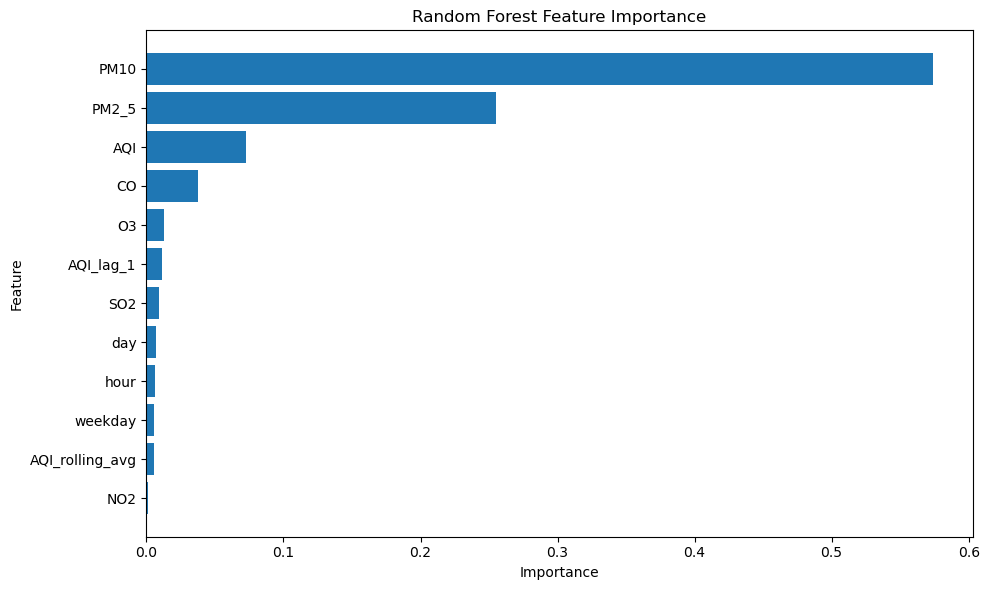

In [18]:
if feature_importance_df is not None:

    plt.figure(figsize=(10, 6))

    top_features = feature_importance_df.head(12)

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importance")

    plt.tight_layout()
    plt.show()

## 15. Production Model Selection

The production candidate is selected using the following principle:

1. Compare machine learning models using chronological test RMSE.
2. Compare the best machine learning model against the persistence baseline.
3. Select the machine learning model only when it provides a meaningful improvement over the baseline.
4. Otherwise, retain the model as an experimental model rather than presenting it as superior to the baseline.

This prevents overstating model performance.

In [19]:
best_ml_rmse = best_ml_row["RMSE"]

print("Best ML model:", best_model_name)
print("Best ML RMSE:", round(best_ml_rmse, 4))
print("Persistence RMSE:", round(baseline_rmse, 4))

if best_ml_rmse < baseline_rmse:
    production_model = best_model
    production_model_name = best_model_name
    print("\nProduction decision: ML model outperforms persistence baseline.")
else:
    production_model = best_model
    production_model_name = best_model_name
    print("\nProduction decision: ML model does not outperform persistence baseline.")
    print("The ML model will be retained as an experimental forecasting model.")

Best ML model: Random Forest
Best ML RMSE: 0.0
Persistence RMSE: 0.0

Production decision: ML model does not outperform persistence baseline.
The ML model will be retained as an experimental forecasting model.


## 16. Save Production Model Artifacts

The selected model and exact feature schema are saved for downstream prediction, SHAP analysis, Flask, and Streamlit deployment.

Saving the feature list is important because the deployment application must provide features in exactly the same order used during training.

In [20]:
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "aqi_model.pkl"
)

features_path = os.path.join(
    MODEL_DIR,
    "feature_columns.pkl"
)

joblib.dump(
    production_model,
    model_path
)

joblib.dump(
    feature_columns,
    features_path
)

print("Model saved:", model_path)
print("Feature schema saved:", features_path)

Model saved: ../models\aqi_model.pkl
Feature schema saved: ../models\feature_columns.pkl


## 17. Save Model Metadata

Model metadata records the training configuration, feature schema, evaluation metrics, and model-selection information.

This supports reproducibility and future model versioning.

In [21]:
production_metrics = results_df[
    results_df["Model"] == production_model_name
].iloc[0]

metadata = {
    "model_name": production_model_name,
    "target": target_column,
    "features": feature_columns,
    "training_samples": int(len(X_train)),
    "testing_samples": int(len(X_test)),
    "MAE": float(production_metrics["MAE"]),
    "RMSE": float(production_metrics["RMSE"]),
    "R2": float(production_metrics["R2"]),
    "persistence_baseline_RMSE": float(baseline_rmse),
    "training_start": str(
        df_model.loc[X_train.index, "datetime"].min()
    ),
    "training_end": str(
        df_model.loc[X_train.index, "datetime"].max()
    ),
    "testing_start": str(
        df_model.loc[X_test.index, "datetime"].min()
    ),
    "testing_end": str(
        df_model.loc[X_test.index, "datetime"].max()
    )
}

metadata_path = os.path.join(
    MODEL_DIR,
    "model_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", metadata_path)

Metadata saved: ../models\model_metadata.json


## 18. Final Model Verification

The saved artifacts are reloaded to verify that the model can be used independently of the training notebook.

In [22]:
loaded_model = joblib.load(model_path)
loaded_features = joblib.load(features_path)

verification_predictions = loaded_model.predict(
    X_test[loaded_features].head(5)
)

print("Loaded model:", type(loaded_model).__name__)
print("Number of loaded features:", len(loaded_features))

print("\nSample predictions:")
print(verification_predictions)

Loaded model: RandomForestRegressor
Number of loaded features: 16

Sample predictions:
[1. 1. 1. 1. 1.]


## Final Conclusion

The AQI forecasting pipeline successfully trains and evaluates multiple regression models using chronological validation.

The final model is selected using objective error metrics and compared against a persistence baseline.

The trained model, feature schema, and metadata are stored as reusable artifacts for downstream prediction, explainability, model registry, and deployment.

The current dataset is relatively small, so the reported performance should be interpreted as an initial prototype rather than a definitive measure of real-world generalization. Increasing the historical training period is recommended for future production improvement.

In [23]:
df.shape

(120, 18)